# Program 8 - YOLO Object Detection — Complete Implementation

## 1. 📦 Installation

In [2]:
# Install Ultralytics (includes YOLOv8)
!pip install ultralytics opencv-python-headless matplotlib Pillow

# Verify installation
import ultralytics
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.4/8062.4 GB disk)


## 2. 📥 Import Libraries

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from IPython.display import display, Image as IPImage
from ultralytics import YOLO

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 3. 🤖 Load Pretrained YOLOv8 Model

| Model | Size | mAP50-95 | Speed (CPU) |
|-------|------|----------|-------------|
| yolov8n | Nano | 37.3 | 80ms |
| yolov8s | Small | 44.9 | 128ms |
| yolov8m | Medium | 50.2 | 234ms |
| yolov8l | Large | 52.9 | 375ms |
| yolov8x | XLarge | 53.9 | 479ms |

In [4]:
# Load YOLOv8 Nano (fast) — change to 'yolov8s.pt', 'yolov8m.pt' for more accuracy
model = YOLO('yolov8n.pt')  # Auto-downloads on first run

print(f"✅ Model loaded: {model.info()}")
print(f"📦 Number of classes: {len(model.names)}")
print(f"🏷️  Class names (first 10): {list(model.names.values())[:10]}")

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
✅ Model loaded: (129, 3157200, 0, 8.8575488)
📦 Number of classes: 80
🏷️  Class names (first 10): ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


## 4. 🖼️ Inference on a Single Image

In [5]:
# ---- Option A: Use a URL image ----
IMAGE_URL = 'https://ultralytics.com/images/bus.jpg'

# Run inference
results = model.predict(source=IMAGE_URL, conf=0.5, save=False)

# Show results
for r in results:
    boxes = r.boxes
    print(f"\n📊 Detections found: {len(boxes)}")
    for i, box in enumerate(boxes):
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]
        xyxy = box.xyxy[0].tolist()
        print(f"  [{i+1}] {label:15s} | Confidence: {conf:.2%} | BBox: [{int(xyxy[0])},{int(xyxy[1])},{int(xyxy[2])},{int(xyxy[3])}]")


image 1/1 /kaggle/working/bus.jpg: 640x480 3 persons, 1 bus, 73.6ms
Speed: 10.5ms preprocess, 73.6ms inference, 42.2ms postprocess per image at shape (1, 3, 640, 480)

📊 Detections found: 4
  [1] bus             | Confidence: 87.34% | BBox: [22,231,805,756]
  [2] person          | Confidence: 86.57% | BBox: [48,398,245,902]
  [3] person          | Confidence: 85.28% | BBox: [669,392,809,877]
  [4] person          | Confidence: 82.52% | BBox: [221,405,344,857]


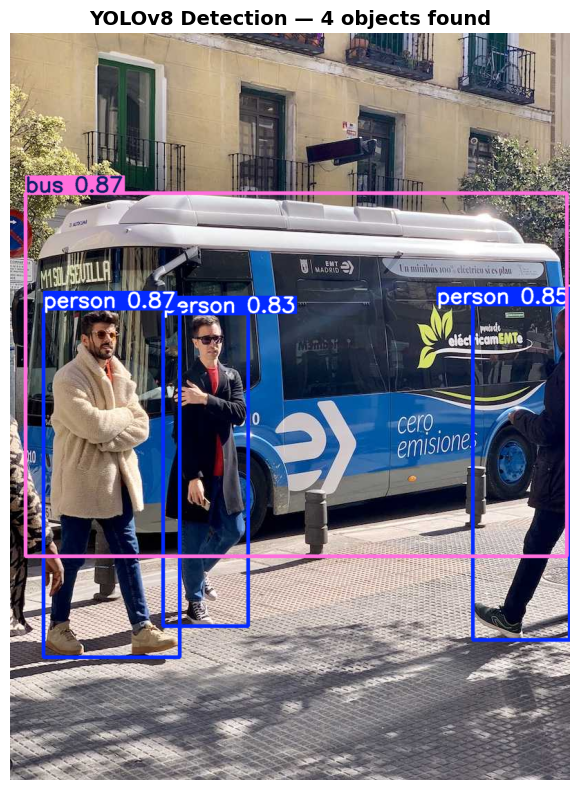

In [6]:
# Visualize detection results
def plot_results(results, figsize=(14, 8)):
    for r in results:
        img_array = r.plot()          # BGR numpy array with boxes drawn
        img_rgb   = img_array[:, :, ::-1]  # Convert BGR → RGB
        plt.figure(figsize=figsize)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"YOLOv8 Detection — {len(r.boxes)} objects found", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_results(results)

## 5. 📁 Inference on Your Own Local Image


image 1/1 /kaggle/input/models/vineetm1204/test/other/default/1/2022-02-04-test_image.jpg: 416x640 2 persons, 1 bicycle, 1 car, 52.2ms
Speed: 2.2ms preprocess, 52.2ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 640)


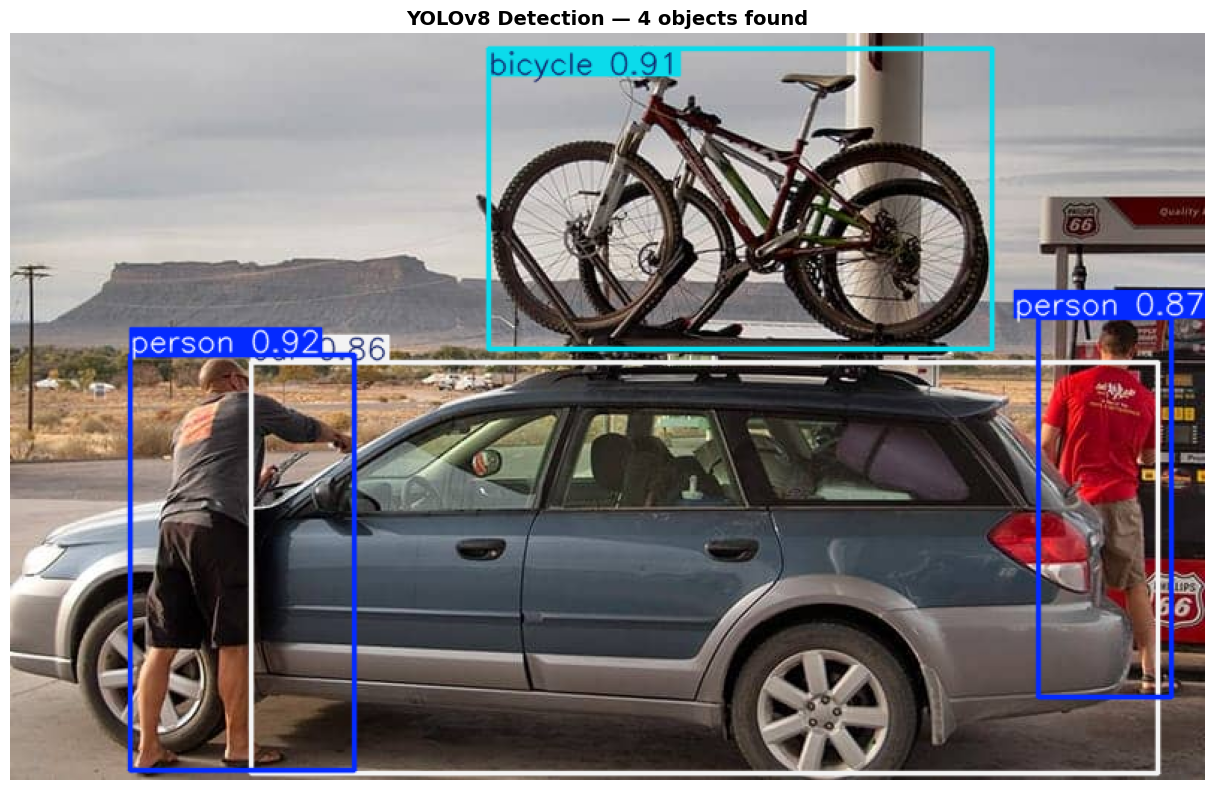

In [7]:
# ---- Option B: Local file upload ----
# Uncomment and set your image path:
IMAGE_PATH = '/kaggle/input/models/vineetm1204/test/other/default/1/2022-02-04-test_image.jpg'

# For Google Colab — upload a file interactively:
# from google.colab import files
# uploaded = files.upload()
# IMAGE_PATH = list(uploaded.keys())[0]

results = model.predict(source=IMAGE_PATH, conf=0.5, save=False)
plot_results(results)

# print("📌 Uncomment the lines above and set your image path to run on a local image.")

## 6. 🎬 Inference on Video

In [8]:
def run_video_detection(video_path, output_path='output_detected.mp4', conf=0.5):
    """
    Run YOLO detection on a video file and save the output.
    
    Args:
        video_path  : Path to input video
        output_path : Path to save annotated video
        conf        : Confidence threshold
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("❌ Error: Cannot open video file.")
        return
    
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"📹 Video: {width}x{height} @ {fps}fps | Total frames: {total}")
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        results = model.predict(frame, conf=conf, verbose=False)
        annotated = results[0].plot()
        out.write(annotated)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"  Processed {frame_count}/{total} frames...", end='\r')
    
    cap.release()
    out.release()
    print(f"\n✅ Done! Output saved to: {output_path}")


# Usage:
# run_video_detection('your_video.mp4', 'output.mp4', conf=0.5)
print("📌 Call run_video_detection('your_video.mp4') to process a video.")

📌 Call run_video_detection('your_video.mp4') to process a video.


## 7. 📷 Webcam / Real-Time Detection (Local Jupyter Only)

In [9]:
def run_webcam_detection(conf=0.5, device_index=0):
    """
    Real-time YOLO detection using webcam.
    Press 'q' to quit.
    
    NOTE: Works in local Jupyter only, not in Colab/remote environments.
    """
    cap = cv2.VideoCapture(device_index)
    print("🎥 Webcam started. Press 'q' to quit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        results  = model.predict(frame, conf=conf, verbose=False)
        annotated = results[0].plot()
        
        # FPS overlay
        cv2.putText(annotated, f"Objects: {len(results[0].boxes)}",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        cv2.imshow('YOLOv8 Real-Time Detection', annotated)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    print("✅ Webcam closed.")


# Uncomment to run:
# run_webcam_detection(conf=0.5)
print("📌 Uncomment the last line to start webcam detection.")

📌 Uncomment the last line to start webcam detection.


## 8. 🏋️ Custom Training on Your Own Dataset

### Dataset format expected (YOLO format):
```
dataset/
├── images/
│   ├── train/   ← training images (.jpg/.png)
│   └── val/     ← validation images
└── labels/
    ├── train/   ← .txt annotations (one per image)
    └── val/
```

Each `.txt` label file line: `class_id cx cy width height` (all normalized 0–1)

In [10]:
# ---- Create a sample dataset YAML ----
import yaml

dataset_config = {
    'path': './dataset',          # Root path of your dataset
    'train': 'images/train',     # Relative path to training images
    'val':   'images/val',       # Relative path to validation images
    'nc':    2,                  # Number of classes
    'names': ['cat', 'dog']      # Class names — customize these!
}

with open('custom_dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print("✅ Dataset config saved to custom_dataset.yaml")
print("\n📄 Content:")
print(yaml.dump(dataset_config))

✅ Dataset config saved to custom_dataset.yaml

📄 Content:
names:
- cat
- dog
nc: 2
path: ./dataset
train: images/train
val: images/val



In [12]:
# ---- Training ----
model = YOLO('yolov8n.pt')  # Start from pretrained weights (recommended)

results = model.train(
    data    = 'custom_dataset.yaml',
    epochs  = 100,
    imgsz   = 640,
    batch   = 16,
    device  = 0,          # GPU index; use 'cpu' if no GPU
    name    = 'my_yolo_run',
    patience= 20,         # Early stopping patience
    lr0     = 0.01,       # Initial learning rate
    workers = 4
)

print("✅ Training complete! Best weights saved at:")
print(results.save_dir)

# print("📌 Uncomment the training block above after setting up your dataset YAML.")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_yolo_run-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pers

RuntimeError: Dataset 'custom_dataset.yaml' error ❌ Dataset 'custom_dataset.yaml' images not found, missing path '/kaggle/working/datasets/dataset/images/val'
Note dataset download directory is '/kaggle/working/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

## 9. 📊 Evaluate the Model (mAP, Precision, Recall)

In [17]:
# Validate on COCO128 (built-in small dataset)
val_results = model.val(data='coco128.yaml', imgsz=640)

print("\n📈 Validation Metrics:")
print(f"  mAP50      : {val_results.box.map50:.4f}")
print(f"  mAP50-95   : {val_results.box.map:.4f}")
print(f"  Precision  : {val_results.box.mp:.4f}")
print(f"  Recall     : {val_results.box.mr:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/kaggle/working/datasets/coco128/images/train2017'
Unzipping /kaggle/working/datasets/coco128.zip to /kaggle/working/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.8Kfiles/s 0.1s
Dataset download success ✅ (0.4s), saved to /kaggle/working/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 943.0±225.0 MB/s, size: 50.9 KB)
val: Scanning /kaggle/working/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 1.1Kit/s 0.1s<0.1s
val: New cache created: /kaggle/working/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.6s0.2ss
                   all        128        929      0.639      0.536      0.

## 10. 💾 Export Model (ONNX, TFLite, TensorRT)

In [18]:
# Export to ONNX (most portable format)
export_path = model.export(format='onnx', imgsz=640, simplify=True)
print(f"✅ ONNX model exported to: {export_path}")

# Other supported formats:
# model.export(format='tflite')      # TensorFlow Lite (mobile)
# model.export(format='torchscript') # TorchScript
# model.export(format='engine')      # TensorRT (NVIDIA GPU only)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 380ms
Prepared 2 packages in 388ms
Installed 2 packages in 17ms
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.1s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (3.5s)
Results saved to /kaggle/working/yolov8n.onnx
Predict:         y

## 11. 📉 Plot Training Metrics (After Training)

In [21]:
import pandas as pd

def plot_training_results(results_csv_path):
    """
    Plot training curves from results.csv generated by YOLO training.
    
    Args:
        results_csv_path: Path to results.csv in the training run folder
    """
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('YOLOv8 Training Results', fontsize=16, fontweight='bold')
    
    metrics = [
        ('train/box_loss',   'Training Box Loss',     'blue'),
        ('train/cls_loss',   'Training Class Loss',   'orange'),
        ('metrics/mAP50(B)', 'Validation mAP@0.5',   'green'),
        ('metrics/precision(B)', 'Precision',         'red'),
        ('metrics/recall(B)',    'Recall',            'purple'),
        ('val/box_loss',     'Validation Box Loss',   'brown'),
    ]
    
    for ax, (col, title, color) in zip(axes.flat, metrics):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f'{title} (not found)', color='gray')
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot saved as training_results.png")


# Usage after training:
# plot_training_results('runs/detect/my_yolo_run/results.csv')
print("📌 Call plot_training_results('path/to/results.csv') after training.")

📌 Call plot_training_results('path/to/results.csv') after training.


## 12. 🔍 Batch Inference on a Folder of Images

In [22]:
def batch_inference(image_folder, output_folder='batch_output', conf=0.5):
    """
    Run YOLO detection on all images in a folder.
    
    Args:
        image_folder  : Folder containing input images
        output_folder : Folder to save annotated images
        conf          : Confidence threshold
    """
    from pathlib import Path
    
    input_dir  = Path(image_folder)
    output_dir = Path(output_folder)
    output_dir.mkdir(exist_ok=True)
    
    image_files = list(input_dir.glob('*.jpg')) + \
                  list(input_dir.glob('*.jpeg')) + \
                  list(input_dir.glob('*.png'))
    
    print(f"📁 Found {len(image_files)} images in {image_folder}")
    
    summary = []
    for img_path in image_files:
        results = model.predict(str(img_path), conf=conf, verbose=False)
        annotated = results[0].plot()
        
        out_path = output_dir / img_path.name
        cv2.imwrite(str(out_path), annotated)
        
        detections = [(model.names[int(b.cls[0])], float(b.conf[0]))
                      for b in results[0].boxes]
        summary.append({'image': img_path.name, 'detections': detections})
    
    print(f"✅ Results saved to: {output_folder}/")
    
    # Print summary
    print("\n📋 Detection Summary:")
    for item in summary:
        print(f"  {item['image']}: {len(item['detections'])} objects → ", end='')
        print(', '.join([f"{d[0]}({d[1]:.0%})" for d in item['detections'][:5]]))
    
    return summary


# Usage:
# summary = batch_inference('./my_images/', './results/')
print("📌 Call batch_inference('folder_path') to run on all images in a folder.")

📌 Call batch_inference('folder_path') to run on all images in a folder.


## 13. 🛠️ Utility: Draw Custom Bounding Boxes

In [23]:
def draw_detections(image_path, results, conf_thresh=0.5):
    """
    Custom visualization of YOLO detection results using matplotlib.
    """
    img = np.array(Image.open(image_path).convert('RGB'))
    
    fig, ax = plt.subplots(1, figsize=(14, 9))
    ax.imshow(img)
    
    COLORS = plt.cm.get_cmap('tab20', len(model.names))
    
    for box in results[0].boxes:
        conf = float(box.conf[0])
        if conf < conf_thresh:
            continue
        
        cls   = int(box.cls[0])
        label = model.names[cls]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        color = COLORS(cls)
        
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5, f"{label} {conf:.0%}",
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
        )
    
    ax.set_axis_off()
    ax.set_title(f'Custom Detections on {Path(image_path).name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("📌 Call draw_detections('image.jpg', results) for custom matplotlib visualization.")

📌 Call draw_detections('image.jpg', results) for custom matplotlib visualization.
